In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt # visualizing data
%matplotlib inline
import seaborn as sns

In [6]:
df=pd.read_csv('Customer Churn.csv')

In [7]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

# we need to replace the blank values of Total charges column into 0 as the tennure of the customers ie 0

In [16]:
df['TotalCharges']=df['TotalCharges'].replace(' ','0')

In [17]:
df['TotalCharges']=df['TotalCharges'].astype(float)

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

# To check the dataframe with null values and their description

In [20]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [21]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


# Always check duplicate in the dataframe and specially with the primary key column

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df['customerID'].duplicated().sum()

np.int64(0)

In [26]:
def conv(value):
    if value == 1:
        return 'Yes'
    else:
        return 'No'
df['SeniorCitizen']=df['SeniorCitizen'].apply(conv)

# We have converted the column value of SeniorCitizen from 0/1 to Yes/No to make the data simple

In [28]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,Yes,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes
7042,3186-AJIEK,Male,No,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.50,No


# Show the Data based on count and %age of Churned customers

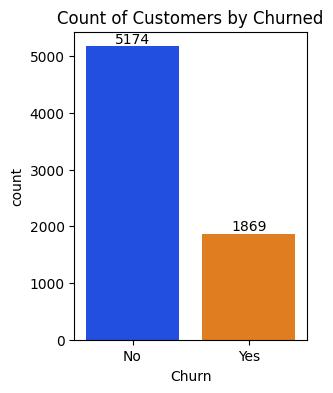

In [53]:
plt.figure(figsize = (3,4))
ax=sns.countplot(x='Churn',data=df,hue = 'Churn',palette='bright') 
for container in ax.containers:
    ax.bar_label(container)
plt.title('Count of Customers by Churned')
plt.show()

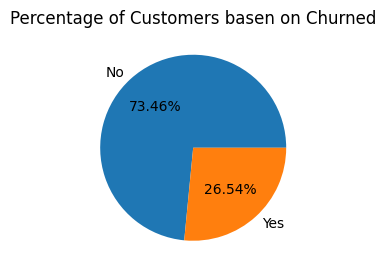

In [37]:
plt.figure(figsize = (3,4))
gb=df.groupby('Churn').agg({'Churn':'count'})
plt.pie(gb['Churn'],labels=gb.index, autopct='%1.2f%%')
plt.title('Percentage of Customers basen on Churned')
plt.show()

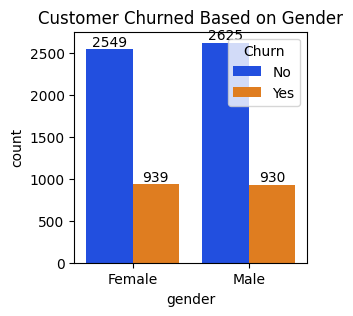

In [52]:
plt.figure(figsize=(3,3))
ax=sns.countplot(x='gender',data=df,hue='Churn',palette='bright')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Customer Churned Based on Gender')
plt.show()

# As we see the count of churned customers based on gender we conclude that gender is not affecting the churning count both Male and Female are almost same count of churned.

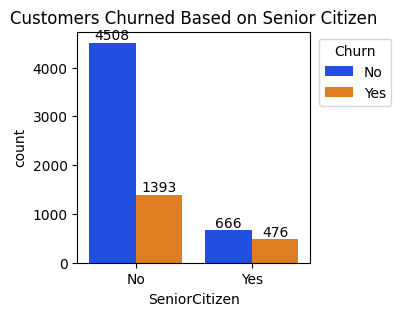

In [59]:
plt.figure(figsize=(3,3))
ax=sns.countplot(x='SeniorCitizen',data=df,hue='Churn',palette='bright')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Customers Churned Based on Senior Citizen')
ax.legend(title='Churn', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.show()

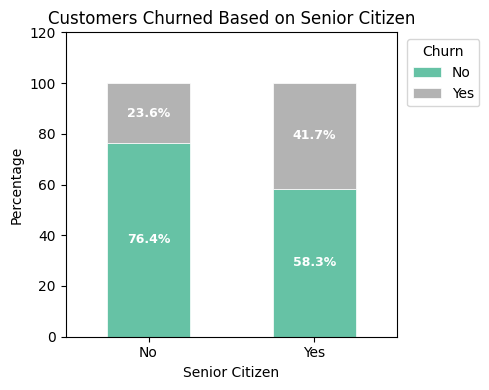

In [58]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

# Calculate percentages
ct = pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index') * 100

# Plot
fig, ax = plt.subplots(figsize=(5, 4))
ct.plot(kind='bar', stacked=True, ax=ax, colormap='Set2', edgecolor='white', linewidth=0.5)

# Add percentage labels inside each segment
for bars in ax.containers:
    labels = [f'{v:.1f}%' if v > 4 else '' for v in bars.datavalues]
    ax.bar_label(bars, labels=labels, label_type='center', fontsize=9, color='white', fontweight='bold')

ax.set_ylim(0, 120)
#ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Senior Citizen')
ax.set_ylabel('Percentage')
ax.set_title('Customers Churned Based on Senior Citizen')
ax.legend(title='Churn', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# A big mass of sinior citizens have churned 

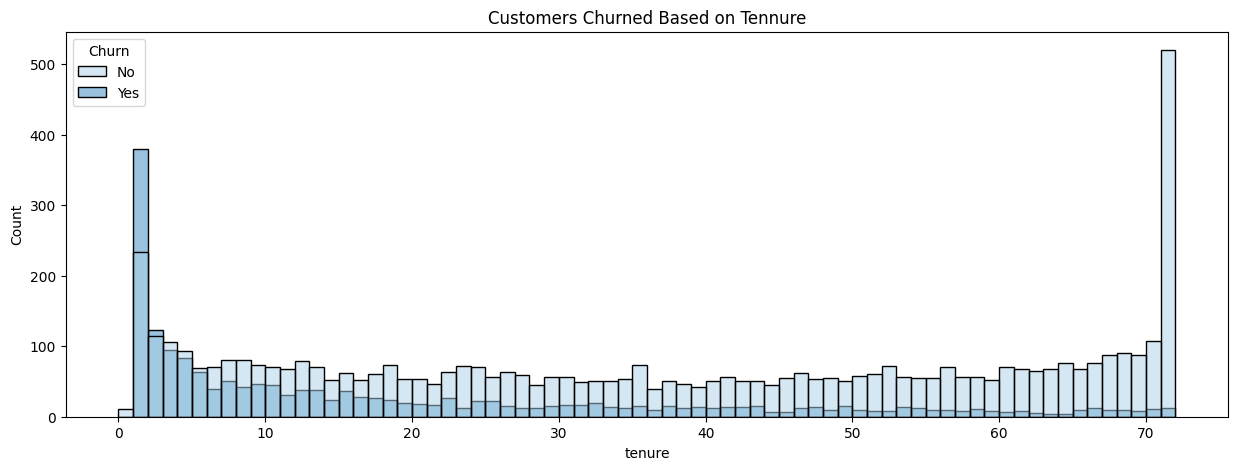

In [69]:
plt.figure(figsize=(15,5))
sns.histplot(x='tenure',data=df,bins=72,hue='Churn',palette='Blues')
plt.title('Customers Churned Based on Tennure')
plt.show()

In [71]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

# People churned the service in the starting phase mostly specially in first and second month

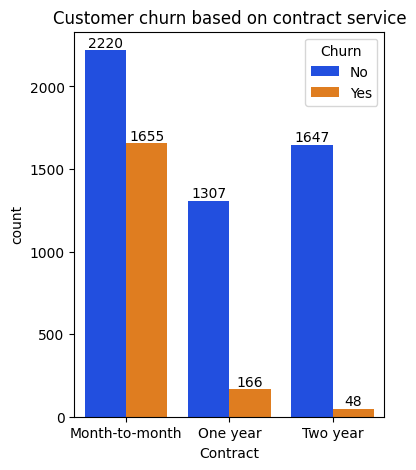

In [78]:
plt.figure(figsize=(4,5))
ax=sns.countplot(x='Contract',data=df,hue='Churn',palette='bright')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Customer churn based on contract service')
plt.show()

# People who have longer contract are churning less and who have shorter contract which is month to month are churning the service on large scale

In [81]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

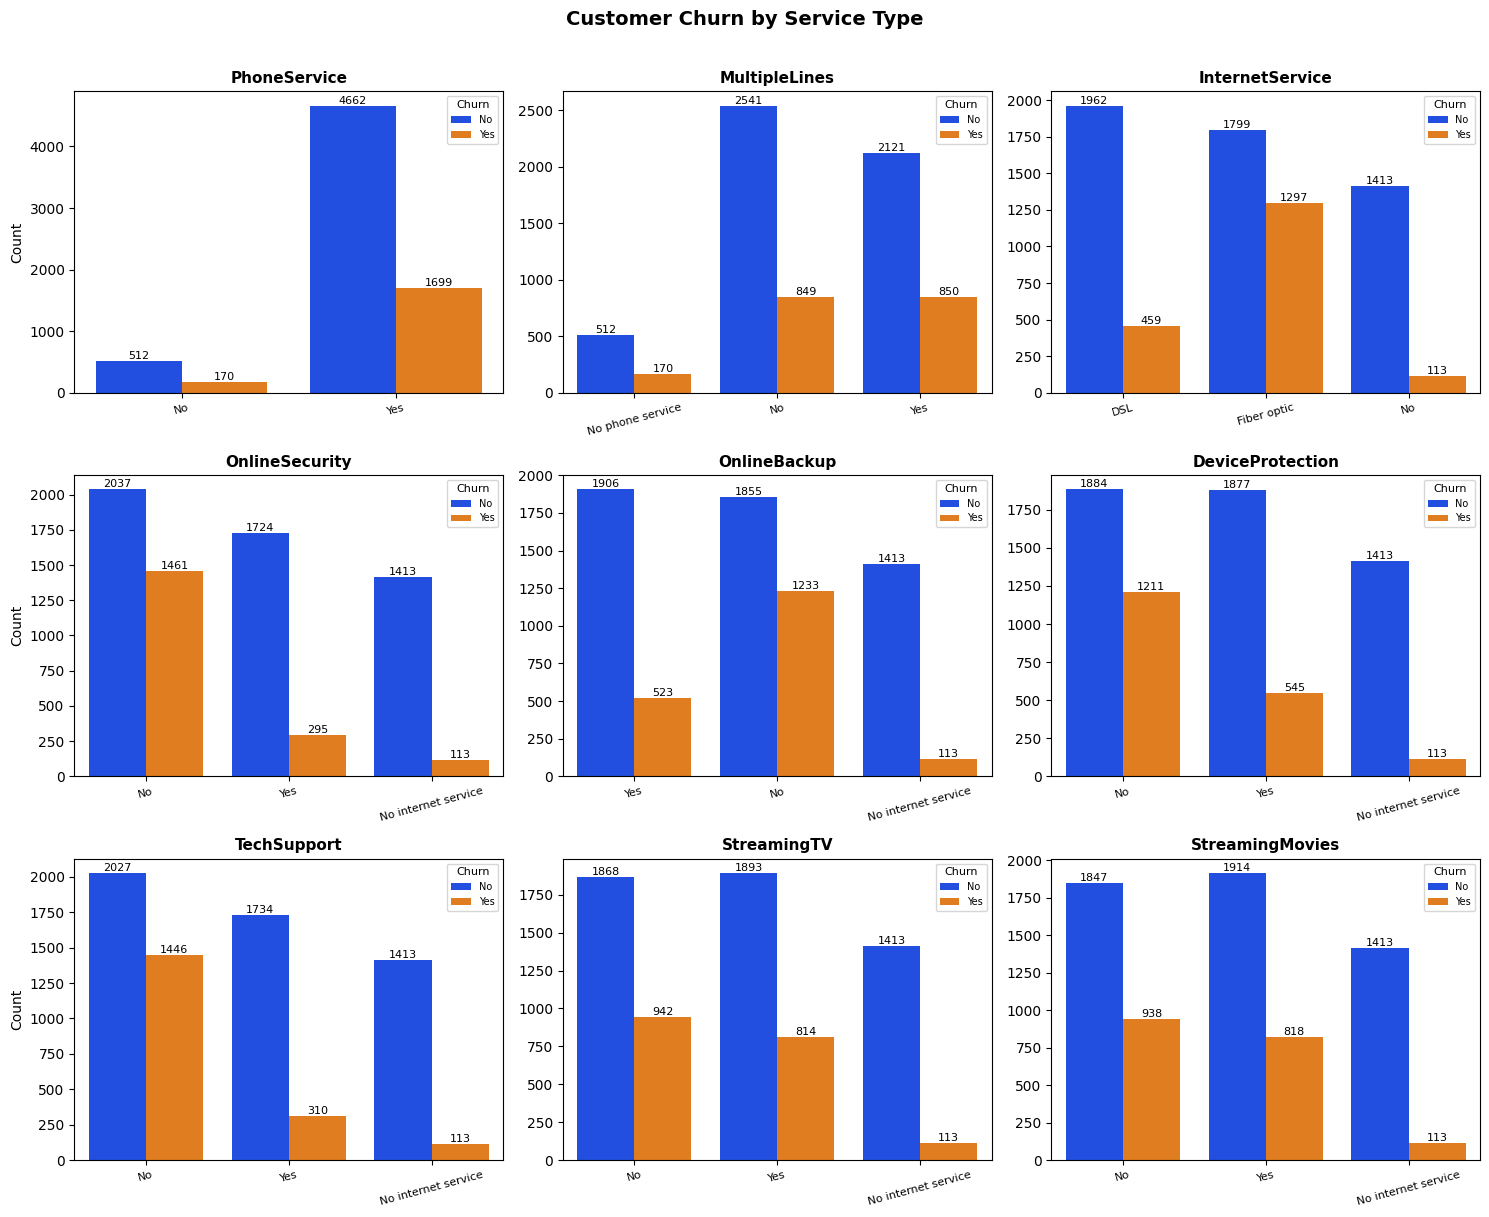

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

service_cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(service_cols):
    ax = axes[i]
    sns.countplot(x=col, data=df, hue='Churn', palette='bright', ax=ax)
    
    # Add bar labels
    for container in ax.containers:
        ax.bar_label(container, fontsize=8)
    
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count' if i % 3 == 0 else '')
    ax.tick_params(axis='x', labelsize=8, rotation=15)
    ax.legend(title='Churn', fontsize=7, title_fontsize=8)

fig.suptitle('Customer Churn by Service Type', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

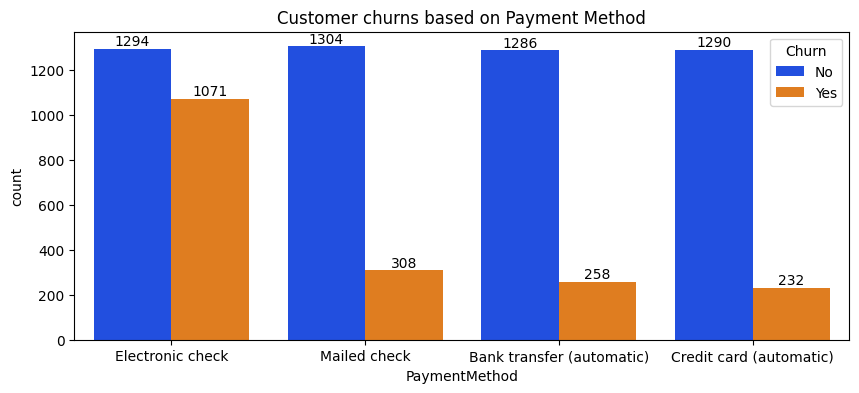

In [88]:
plt.figure(figsize=(10,4))
ax=sns.countplot(x='PaymentMethod',data=df,hue='Churn',palette='bright')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Customer churns based on Payment Method')
plt.show()

# Customers who pays through electronic check churns on mass level rather than other payment opstion